# Лабораторная работа 6

Тема: **Оптимизация и скорость сходимости: шаг обучения и выбор оптимизатора**  
Цель: на одной и той же модели и датасете (MNIST + простой MLP) **экспериментально** исследовать, как ведут себя разные значения `learning_rate` и разные оптимизаторы (SGD, SGD+Momentum, Adam), и сформулировать свои практические правила выбора.

> Этот ноутбук предназначен именно для вашей самостоятельной работы.  
> Его структура и код — каркас, а содержание (графики, комментарии, выводы) должны отражать **ваши эксперименты и ваш стиль объяснения**.
> Если вы попытаетесь автоматически сгенерировать текст целиком, это будет заметно по общей, оторванной от ваших графиков формулировке.


## 1. Ваши ожидания до экспериментов

Прежде чем смотреть на реальные кривые, зафиксируйте, что вы **ожидаете** увидеть.

Ответьте своими словами:
1. Что, по вашему интуитивному ощущению, происходит с обучением при **очень маленьком** шаге (`lr`): по loss, по времени сходимости, по точности?  
2. Что может пойти не так при **слишком большом** шаге (`lr`), если смотреть на графики loss/accuracy?  
3. Чем вы ожидаете, что будет отличаться поведение **SGD**, **SGD с momentum** и **Adam** на задаче вроде MNIST (скорость сходимости, чувствительность к выбору lr, «рывки» на графиках и т.п.)?

Напишите ответы в свободной форме (6–10 предложений). Важно, чтобы это были именно ваши формулировки, а не пересказ учебника.


In [2]:
expectations_text = """
1) Очень маленький lr: loss падает медленно, обучение идет долго, точность не успевает вырасти.
2) Слишком большой lr: loss растет, точность нестабильная.
3) SGD - медленный, но зависит от lr. SGD с momentum - быстрее, но если двигается в правильную сторону.
Adam - сам подбирает шаг для веса. Здесь будет быстрее сходимость и наименьшее чувствительность к lr.
"""
print(expectations_text)


1) Очень маленький lr: loss падает медленно, обучение идет долго, точность не успевает вырасти.
2) Слишком большой lr: loss растет, точность нестабильная.
3) SGD - медленный, но зависит от lr. SGD с momentum - быстрее, но если двигается в правильную сторону.
Adam - сам подбирает шаг для веса. Здесь будет быстрее сходимость и наименьшее чувствительность к lr.



## 2. Импорт библиотек и настройка среды

Здесь всё стандартно:
- импорт PyTorch, torchvision и вспомогательных библиотек;
- фиксация `seed` (одно число, которое вы сможете назвать на защите);
- определение устройства (`cpu` или `cuda`).


In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# ВАШ ЛИЧНЫЙ SEED (можете выбрать любое число, но потом не меняйте его без причины)
MY_SEED = 11
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cpu
MY_SEED = 11


## 3. Данные MNIST и DataLoader

Используем набор рукописных цифр MNIST.  
Ваша задача:
- задать трансформации (как минимум `ToTensor` + нормализация);
- загрузить обучающую и тестовую части;
- создать `DataLoader` с разумным `batch_size`.

Размер батча вы выбираете сами (например, 64 или 128), главное потом объяснить выбор по-человечески: чем он удобен именно для этой работы.


In [3]:
batch_size = 64  # TODO: поменять и прокомментировать выбор в выводах
# за одну эпоху получается примерно 938 шагов.
# Это нормальный баланс: не слишком мало (градиент стабильный), и не слишком много (остаётся немного «шума», полезного для обучения).
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("train size =", len(train_dataset))
print("test size  =", len(test_dataset))
print("batch_size =", batch_size)

train size = 60000
test size  = 10000
batch_size = 64


Если вы хотите для спокойствия посмотреть на пару примеров изображений — можете добавить сюда небольшой блок визуализации (по образцу ЛР4–5). Это не обязательно, но иногда помогает ощутить задачу глазами.


## 4. Модель (фиксированная для всех экспериментов)

Чтобы сравнение оптимизаторов и `learning_rate` было честным, архитектура модели должна оставаться **одна и та же** во всех прогонах.

Возьмём простой MLP:
- вход: 28×28 → разворачиваем в вектор длины 784;
- два скрытых слоя с ReLU (например, 256 и 128 нейронов);
- выход: 10 логитов (по одному на цифру 0–9).

Эту архитектуру **не меняем** в рамках лабораторной (если измените — **обязательно явно зафиксируйте это в отчёте**).


In [5]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

print(SimpleMLP())
total = sum(p.numel() for p in SimpleMLP().parameters())
print(f"\nВсего параметров: {total:,}")

SimpleMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

Всего параметров: 235,146


## 5. Общие функции обучения и оценки

Напишем функции `train_one_epoch` и `evaluate`.  
Их вы использовали в прошлых работах; сейчас они понадобятся, чтобы собирать **историю** обучения для разных конфигураций.


In [6]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            running_correct += (preds == labels).sum().item()
            total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


## 6. Универсальная функция запуска одного эксперимента

Чтобы не копировать один и тот же код для разных настроек, напишем функцию `run_experiment`, которая:
- создаёт новую модель `SimpleMLP`;
- инициализирует оптимизатор (SGD / SGD+Momentum / Adam) с нужными параметрами;
- обучает модель `num_epochs` эпох;
- возвращает историю значений `train_loss`, `train_acc`, `test_loss`, `test_acc`.

Такой формат удобно использовать для честного сравнения разных конфигураций.


In [7]:
def run_experiment(config_name, optimizer_class, optimizer_kwargs,
                   num_epochs=8):
    print("\n=== Конфигурация:", config_name, "===")

    model = SimpleMLP().to(device)
    optimizer = optimizer_class(model.parameters(), **optimizer_kwargs)

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, device)
        test_loss, test_acc = evaluate(model, test_loader, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(f"Эпоха {epoch}/{num_epochs} | "
              f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
              f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

    return history

print("Функция run_experiment готова.")

Функция run_experiment готова.


## 7. Набор конфигураций для сравнения

Рекомендуемый набор (можете расширить):

- `SGD lr=0.001` — заведомо небольшой шаг;  
- `SGD lr=0.01` — разумный кандидат;  
- `SGD lr=0.5` — намеренно большой шаг, чтобы увидеть нестабильность;  
- `SGD lr=0.01, momentum=0.9` — добавляем momentum и смотрим, что изменится;  
- `Adam lr=0.001` — «типичная» настройка для Adam.

Число эпох выберите так, чтобы кривые успели чуть-чуть «устаканиться» (например, 8–12 эпох).


In [8]:
num_epochs = 10  # учитывайте время обучения

histories = []
labels = []

# 1. SGD с маленьким шагом
h_sgd_small = run_experiment(
    config_name="SGD lr=0.001",
    optimizer_class=torch.optim.SGD,
    optimizer_kwargs={"lr": 0.001},
    num_epochs=num_epochs
)
histories.append(h_sgd_small)
labels.append("SGD 0.001")

# 2. SGD с "разумным" шагом
h_sgd_mid = run_experiment(
    config_name="SGD lr=0.01",
    optimizer_class=torch.optim.SGD,
    optimizer_kwargs={"lr": 0.01},
    num_epochs=num_epochs
)
histories.append(h_sgd_mid)
labels.append("SGD 0.01")

# 3. SGD с большим шагом
h_sgd_big = run_experiment(
    config_name="SGD lr=0.5",
    optimizer_class=torch.optim.SGD,
    optimizer_kwargs={"lr": 0.5},
    num_epochs=num_epochs
)
histories.append(h_sgd_big)
labels.append("SGD 0.5")

# 4. SGD с momentum
h_sgdm = run_experiment(
    config_name="SGD lr=0.01, momentum=0.9",
    optimizer_class=torch.optim.SGD,
    optimizer_kwargs={"lr": 0.01, "momentum": 0.9},
    num_epochs=num_epochs
)
histories.append(h_sgdm)
labels.append("SGD+mom 0.01")

# 5. Adam
h_adam = run_experiment(
    config_name="Adam lr=0.001",
    optimizer_class=torch.optim.Adam,
    optimizer_kwargs={"lr": 0.001},
    num_epochs=num_epochs
)
histories.append(h_adam)
labels.append("Adam 0.001")

# 6. Adam lr=0.01
h_adam_big = run_experiment(
    config_name      = "Adam lr=0.01",
    optimizer_class  = torch.optim.Adam,
    optimizer_kwargs = {"lr": 0.01},
    num_epochs       = num_epochs
)
histories.append(h_adam_big)
labels.append("Adam lr=0.01")


=== Конфигурация: SGD lr=0.001 ===
Эпоха 1/10 | train_loss=2.1656, train_acc=0.3877, test_loss=1.9483, test_acc=0.6517
Эпоха 2/10 | train_loss=1.5843, train_acc=0.7088, test_loss=1.1737, test_acc=0.7596
Эпоха 3/10 | train_loss=0.9350, train_acc=0.8036, test_loss=0.7263, test_acc=0.8385
Эпоха 4/10 | train_loss=0.6464, train_acc=0.8510, test_loss=0.5477, test_acc=0.8715
Эпоха 5/10 | train_loss=0.5195, train_acc=0.8706, test_loss=0.4605, test_acc=0.8857
Эпоха 6/10 | train_loss=0.4521, train_acc=0.8818, test_loss=0.4097, test_acc=0.8925
Эпоха 7/10 | train_loss=0.4111, train_acc=0.8888, test_loss=0.3779, test_acc=0.8982
Эпоха 8/10 | train_loss=0.3835, train_acc=0.8937, test_loss=0.3552, test_acc=0.9024
Эпоха 9/10 | train_loss=0.3633, train_acc=0.8977, test_loss=0.3388, test_acc=0.9053
Эпоха 10/10 | train_loss=0.3476, train_acc=0.9013, test_loss=0.3249, test_acc=0.9085

=== Конфигурация: SGD lr=0.01 ===
Эпоха 1/10 | train_loss=0.7398, train_acc=0.8167, test_loss=0.3387, test_acc=0.9042
Эпох

## 8. Визуальное сравнение кривых для разных конфигураций

Теперь важно **на одном графике** увидеть, как ведут себя `train/test loss` и `train/test accuracy` для разных настроек.  
Это поможет сформировать интуицию, а не просто запомнить «Adam хороший, SGD плохой».


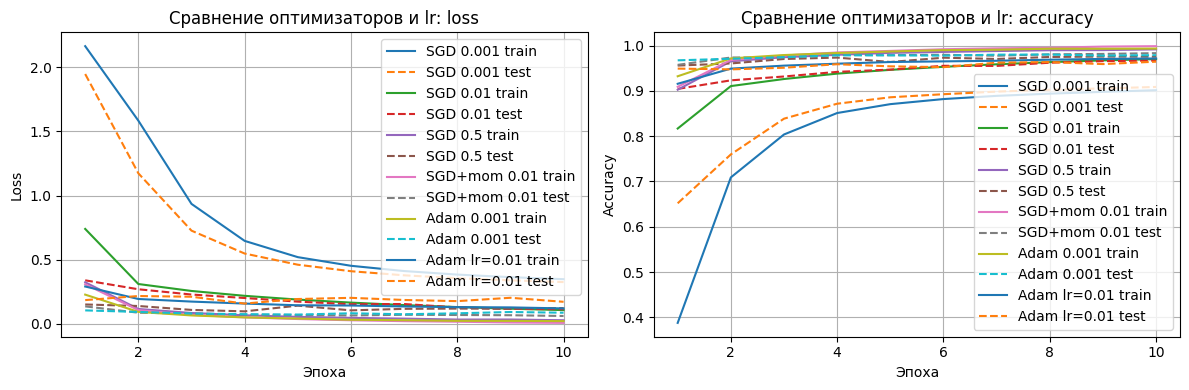

In [9]:
def plot_histories(histories, labels, title_prefix=""):
    plt.figure(figsize=(12, 4))

    # Loss
    plt.subplot(1, 2, 1)
    for hist, label in zip(histories, labels):
        epochs = np.arange(1, len(hist["train_loss"]) + 1)
        plt.plot(epochs, hist["train_loss"], label=f"{label} train")
        plt.plot(epochs, hist["test_loss"], linestyle="--", label=f"{label} test")
    plt.xlabel("Эпоха")
    plt.ylabel("Loss")
    plt.title(title_prefix + "loss")
    plt.grid(True)
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    for hist, label in zip(histories, labels):
        epochs = np.arange(1, len(hist["train_acc"]) + 1)
        plt.plot(epochs, hist["train_acc"], label=f"{label} train")
        plt.plot(epochs, hist["test_acc"], linestyle="--", label=f"{label} test")
    plt.xlabel("Эпоха")
    plt.ylabel("Accuracy")
    plt.title(title_prefix + "accuracy")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_histories(histories, labels, title_prefix="Сравнение оптимизаторов и lr: ")

## 9. Анализ результатов (самая важная часть)

Теперь нужно **словами** описать то, что вы увидели.  
Не переписывайте теорию про оптимизаторы — опирайтесь именно на свои графики и числа.

Попробуйте в одном связанном тексте ответить на такие вопросы:

- Как выглядели кривые для `SGD lr=0.001`: насколько медленно росла точность, успела ли она выйти на разумный уровень за `num_epochs`?  
- Что происходило при `SGD lr=0.5`: были ли скачки loss, «разброс» accuracy, признаки расходимости?  
- Как вёл себя `SGD lr=0.01`: показался ли вам этот шаг «рабочим компромиссом» между скоростью и стабильностью?  
- Что дал `momentum`: стало ли обучение более ровным/быстрым, изменилась ли финальная test accuracy по сравнению с чистым SGD?  
- Как отличался `Adam`: быстрее ли он выходил на высокую точность, как вёл себя test loss, было ли переобучение?

Упоминайте конкретные числа (например, test accuracy на последней эпохе для разных конфигураций) и форму кривых (плавные/рывковые, раннее насыщение и т. п.).


In [3]:
analysis_text = """
1) SGD lr=0.001 - медленнее всех.
В первую эпоху test_acc=0.6517 - остальные конфигурации уже на 0.90–0.95. Кривые loss падают плавно и монотонно, без каких-либо скачков.
Неожиданное наблюдение: train_acc=0.9013 < test_acc=0.9085 - тест оказался лучше трейна.
Разрыв отрицательный: -0.0072. Переобучения нет вообще, так как при lr=0.001 сеть за 10 эпох успела выучить только самые грубые закономерности.

2) SGD lr=0.5 - главный сюрприз. Показал неожиданно хорошие результаты.
SGD lr=0.5 работает и даёт test_acc=0.9753 к эпохе 10 - третий результат среди всех.
Кривые loss плавные, accuracy стабильно растёт. Однако:
train_acc = 0.9915 - сеть почти идеально запомнила трейн, test_acc = 0.9753, разрыв = 0.0162 - самый большой из всех конфигураций.
Несмотря на большой шаг обучения, расходимости не возникло: loss снижался стабильно.

3) SGD lr=0.01 - наиболее сбалансированный вариант.
Ровный, предсказуемый рост. К эпохе 10: train_acc = 0.9700, test_acc = 0.9668, разрыв = 0.0032.
Разрыв train-test - минимальный среди всех рабочих конфигураций: переобучение почти отсутствует.
Кривые loss падают монотонно, без резких скачков.

4) SGD + Momentum lr=0.01, momentum=0.9 - лучший по test_acc.
Добавление momentum ускорило обучение и позволило быстрее достичь высокой точности: test_acc=0.9831. 
Уже на первых эпохах результаты были лучше, чем у обычного SGD: в эпоху 1 - 0.9573, когда чистый SGD lr=0.01 ещё только на 0.9042.
Но сильное переобучение в конце: train_acc = 0.9985, test_acc = 0.9831, разрыв = 0.0154.
С эпохи 6 test_acc застыл (0.9795, 0.9774, 0.9805, 0.9814, 0.9831), а train_acc продолжил лететь (0.9918, 0.9937, 0.9950, 0.9975, 0.9985).
Momentum разогнал сеть настолько, что она запомнила трейн почти идеально.

5) Adam lr=0.001 - самый быстрый старт.
Adam обеспечил самый быстрый рост точности в начале обучения. Уже после первой эпохи test_acc=0.9673 - это лучший старт среди всех. 
Итоговая точность составила test_acc=0.9786, train_acc=0.9932, разрыв=0.0146, но во второй половине обучения test loss начал заметно колебаться. 
При увеличении learning rate до 0.01 результаты ухудшились: итоговая test_acc=0.9643, а loss стал менее стабильным.
Увеличение в 10 раз (до 0.01) заметно ухудшает результат. Разрыв train-test минимальный (0.0071) - переобучения нет, но сама точность низкая.
""" 
print(analysis_text)


1) SGD lr=0.001 - медленнее всех.
В первую эпоху test_acc=0.6517 - остальные конфигурации уже на 0.90–0.95. Кривые loss падают плавно и монотонно, без каких-либо скачков.
Неожиданное наблюдение: train_acc=0.9013 < test_acc=0.9085 - тест оказался лучше трейна.
Разрыв отрицательный: -0.0072. Переобучения нет вообще, так как при lr=0.001 сеть за 10 эпох успела выучить только самые грубые закономерности.

2) SGD lr=0.5 - главный сюрприз. Показал неожиданно хорошие результаты.
SGD lr=0.5 работает и даёт test_acc=0.9753 к эпохе 10 - третий результат среди всех.
Кривые loss плавные, accuracy стабильно растёт. Однако:
train_acc = 0.9915 - сеть почти идеально запомнила трейн, test_acc = 0.9753, разрыв = 0.0162 - самый большой из всех конфигураций.
Несмотря на большой шаг обучения, расходимости не возникло: loss снижался стабильно.

3) SGD lr=0.01 - наиболее сбалансированный вариант.
Ровный, предсказуемый рост. К эпохе 10: train_acc = 0.9700, test_acc = 0.9668, разрыв = 0.0032.
Разрыв train-tes

## 10. Итоговые практические выводы

В конце сформулируйте короткое резюме (5–8 предложений), как будто вы объясняете младшим курсам, **что вы вынесли из этой лабораторной**:

- Какие диапазоны `learning_rate` для SGD вы теперь считаете «слишком маленькими», «рабочими» и «слишком агрессивными» — именно на примере этой задачи.  
- В каких случаях вы бы использовали SGD с momentum, а в каких — достаточно обычного SGD.  
- Когда лично вы после этой работы предпочли бы Adam, а когда — всё-таки остались бы на SGD/SGD+Momentum (например, из-за понятности поведения, чувствительности к lr и т.п.).

Важно, чтобы здесь звучал ваш голос и ссылка на ваш опыт, а не абстрактные фразы про «Adam обычно лучше».


In [2]:
final_conclusion = """
После выполнения работы можно сделать несколько выводов. 
1) Для SGD learning rate 0.001 оказался слишком маленьким: обучение было стабильным, но за 10 эпох модель достигла только 90.85% точности. 
2) Значение 0.01 показало себя как наиболее удачный вариант - обучение было быстрым и стабильным, а переобучение почти отсутствовало. 
3) Learning rate 0.5 дал высокий результат (97.53%), но привёл к заметному переобучению, поэтому такой шаг можно считать слишком агрессивным.
4) Добавление momentum улучшило результаты SGD. Конфигурация SGD + Momentum достигла лучшей test accuracy - 98.31%, а обучение происходило быстрее, чем у обычного SGD. 
Поэтому momentum стоит использовать, когда важна максимальная точность. Обычный SGD подойдёт в случаях, когда нужна более простая и предсказуемая настройка модели.
5) Adam показал самый быстрый старт: уже после первой эпохи точность была выше, чем у всех вариантов SGD. 
Если нужен хороший результат за небольшое число эпох, Adam является удобным выбором. Однако в данном эксперименте лучшую итоговую точность всё же показал SGD с momentum. 
Поэтому для БЫСТРОГО и ПРОСТОГО обучения я бы выбрала Adam, а для получения МАКСИМАЛЬНОГО КАЧЕСТВА - SGD + Momentum.
"""
print(final_conclusion)


После выполнения работы можно сделать несколько выводов. 
1) Для SGD learning rate 0.001 оказался слишком маленьким: обучение было стабильным, но за 10 эпох модель достигла только 90.85% точности. 
2) Значение 0.01 показало себя как наиболее удачный вариант - обучение было быстрым и стабильным, а переобучение почти отсутствовало. 
3) Learning rate 0.5 дал высокий результат (97.53%), но привёл к заметному переобучению, поэтому такой шаг можно считать слишком агрессивным.
4) Добавление momentum улучшило результаты SGD. Конфигурация SGD + Momentum достигла лучшей test accuracy - 98.31%, а обучение происходило быстрее, чем у обычного SGD. 
Поэтому momentum стоит использовать, когда важна максимальная точность. Обычный SGD подойдёт в случаях, когда нужна более простая и предсказуемая настройка модели.
5) Adam показал самый быстрый старт: уже после первой эпохи точность была выше, чем у всех вариантов SGD. 
Если нужен хороший результат за небольшое число эпох, Adam является удобным выбором.